In [1]:
# Importamos la librería Pandas para el análisis y la manipulación de los datos
import pandas as pd

## **Paso 1: Autenticación en Google Colab**

In [2]:
# Autenticamos nuestra sesión con la cuenta de Google
from google.colab import auth
auth.authenticate_user()
print('Autenticado')

Autenticado


## **Paso 2: Crear el cliente de BigQuery**

In [3]:
# Importa la librería oficial de BigQuery, permite que Python se comunique
# con BigQuery mediante la API de Google Cloud
from google.cloud import bigquery

# Ingresa el nombre de nuestro proyecto en Google Cloud
project_id = 'example-491314'

# Se crea un objeto cliente de BigQuery que permite ejecutar
# ejecutar consultas SQL
client = bigquery.Client(project=project_id)

## **Paso 3: Definir las consultas SQL**

In [4]:
# Consulta SQL para obtener los términos más buscados en Estados Unidos
query_eeuu = """
SELECT
  term,
  AVG(percent_gain) AS crecimiento_promedio
FROM
  `bigquery-public-data.google_trends.top_rising_terms`
WHERE
  percent_gain IS NOT NULL
  AND refresh_date >= DATE_SUB(CURRENT_DATE(), INTERVAL 30 DAY)
GROUP BY term
ORDER BY crecimiento_promedio DESC
LIMIT 20;
"""

## **Paso 4: Ejecutar la consulta**

In [5]:
# Enviamos la consulta a Big Query para que se ejecute
query_job_eeuu = client.query(query_eeuu)

## **Paso 5: Objtener los reultados**

In [6]:
# Se devuelve el resultado de la consulta en BigQuery
results_eeuu = query_job_eeuu.result()

## **Paso 6: Visualizar los resultados**

In [7]:
for row in results_eeuu:
    print(f"{row.term} → {round(row.crecimiento_promedio, 2)}%")

men’s march madness → 41400.0%
women’s march madness → 38714.91%
easter traditions → 24725.0%
chuck norris → 17013.19%
robert mueller → 10075.0%
bam adebayo → 6623.42%
nicholas brendon → 5675.0%
meson → 5600.0%
artemis ii → 5577.34%
googol → 5550.0%
ersatz → 5350.0%
yutz → 4950.0%
did chuck norris die → 4651.53%
futz → 4400.0%
pam bondi → 4375.0%
chuck norris death → 4127.34%
carouser → 4100.0%
javert → 3975.0%
quark → 3972.37%
deerstalker → 3825.0%


## **Paso 7: Convertir el resultdo a DataFrame de Pandas**

In [8]:
df_eeuu = query_job_eeuu.to_dataframe()
df_eeuu

,term,crecimiento_promedio
0,men’s march madness,41400.000000
1,women’s march madness,38714.913958
2,easter traditions,24725.000000
3,chuck norris,17013.193117
4,robert mueller,10075.000000
5,bam adebayo,6623.422562
6,nicholas brendon,5675.000000
7,meson,5600.000000
8,artemis ii,5577.342256
9,googol,5550.000000


<Axes: ylabel='term'>

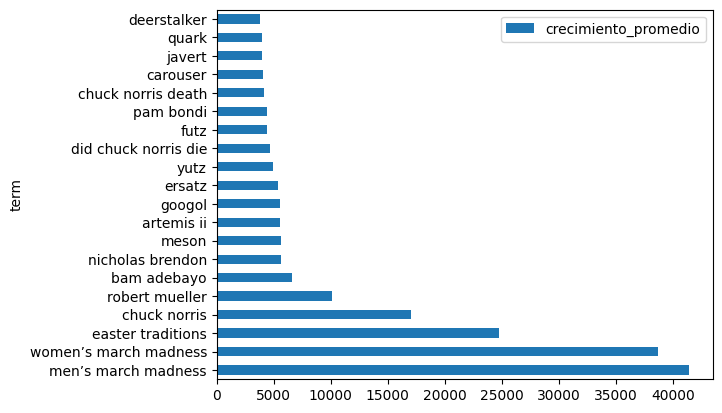

In [9]:
df_eeuu.plot(kind='barh', x='term', y='crecimiento_promedio')

Para el caso de Estados Unidos, se utilizó la tabla de términos en crecimiento (rising terms), calculando el promedio del incremento porcentual (percent_gain) durante los últimos 30 días. Esto permitió identificar los términos que han ganado mayor relevancia recientemente, en lugar de aquellos que solo presentan alta frecuencia.

Chile


## **Paso 2: Crear el cliente de BigQuery**

In [10]:
# Importa la librería oficial de BigQuery, permite que Python se comunique
# con BigQuery mediante la API de Google Cloud
from google.cloud import bigquery

# Ingresa el nombre de nuestro proyecto en Google Cloud
project_id = 'example-491314'

# Se crea un objeto cliente de BigQuery que permite ejecutar
# ejecutar consultas SQL
cliente = bigquery.Client(project=project_id)

## **Paso 3: Definir las consultas SQL**

In [12]:
query_chile = """
SELECT
  term,
  AVG(percent_gain) AS crecimiento_promedio
FROM
  `bigquery-public-data.google_trends.international_top_rising_terms`
WHERE
  country_name = "Chile"
  AND percent_gain IS NOT NULL
  AND refresh_date >= DATE_SUB(CURRENT_DATE(), INTERVAL 30 DAY)
GROUP BY term
ORDER BY crecimiento_promedio DESC
LIMIT 20;
"""

## **Paso 4: Ejecutar la consulta**

In [13]:
# Enviamos la consulta a Big Query para que se ejecute
query_job_chile = cliente.query(query_chile)

## **Paso 5: Objtener los reultados**

In [14]:
# Se devuelve el resultado de la consulta en BigQuery
results_chile = query_job_chile.result()

## **Paso 6: Visualizar los resultados**

In [15]:
for row in results_chile:
    print(row.term, row.crecimiento_promedio)

día del número pi 56689.101338432134
día de san patricio 29475.0
coquimbo unido u. de chile 23500.382409177822
u. de chile univ. concepción 23250.0
real madrid elche c. f. 21876.00382409178
r.c.d. mallorca real madrid 17096.367112810705
u. de chile la serena 17000.000000000004
rojas vade 14244.741873804971
u. católica palestino 13195.793499043977
chuck norris 12549.999999999998
atlético madrid barcelona 12119.694072657745
barcelona sevilla 11875.000000000002
concepción colo-colo 11200.000000000002
cruz johnson 10150.0
u. la calera o'higgins 10075.0
real madrid atlético madrid 10074.999999999998
u. católica everton 9960.70745697897
barcelona rayo vallecano 9875.0
coquimbo unido cobresal 9499.999999999998
eduardo cruz johnson 9150.0


## **Paso 7: Convertir el resultdo a DataFrame de Pandas**

In [16]:
df_chile = query_job_chile.to_dataframe()
df_chile

,term,crecimiento_promedio
0,día del número pi,56689.101338
1,día de san patricio,29475.000000
2,coquimbo unido u. de chile,23500.382409
3,u. de chile univ. concepción,23250.000000
4,real madrid elche c. f.,21876.003824
5,r.c.d. mallorca real madrid,17096.367113
6,u. de chile la serena,17000.000000
7,rojas vade,14244.741874
8,u. católica palestino,13195.793499
9,chuck norris,12550.000000


<Axes: ylabel='term'>

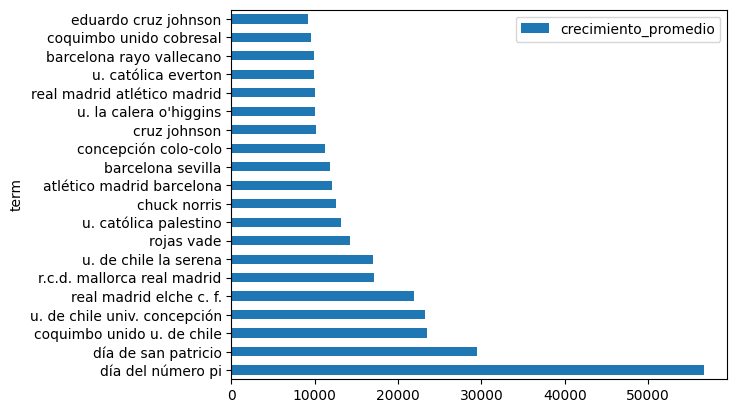

In [17]:
df_chile.plot(kind='barh', x='term', y='crecimiento_promedio')

Se incorporó el análisis de términos en crecimiento (rising terms), utilizando el promedio del incremento porcentual (percent_gain), lo que permite identificar no solo los términos más frecuentes, sino aquellos que están ganando relevancia en el tiempo.


